# Make basic measurements

Make the measurements that are already possible to make with Prez's code. These are:  
* Minimum time taken for the mice to arrive the reward location in a trial. 
    It's only at animal spent > set amount of time, we would say the animal "arrived at the reward". That set amount of time was set to 2s in Prez's code
* Frequency of crossing the reward zone within a trial
* Fraction of time animal stayed at the reward location within a trial

## Helper functions

In [1]:
import sys
sys.path.append('..')
from util.data_loader import DataLoader
import util.utilities as util
import numpy as np
import pandas as pd
from tqdm import tqdm

def add_dist_to_trigger(position, triggerLoc):
    # Add distance to trigger in the position dataframe
    num_triggers = len(triggerLoc)
    for i in range(num_triggers):
        well_x = triggerLoc['x'][i]
        well_y = triggerLoc['y'][i]
        dist_col_name = f'dist_to_trigger_{i+1}'
        position[dist_col_name] = np.sqrt((position['x'].values - well_x)**2 + (position['y'].values - well_y)**2)

    return position

def get_interaction_with_trigger_df(df, r, ti=1):
    '''
    Find each time the mouse enter within radius `r` to trigger `ti`, and find the enter, 
    exit time, and durations of each visit
    '''
    inside = df[f'dist_to_trigger_{ti}'] <= r
    # Sometime animal started at the trigger zone by mistake. Set the first inside to False
    inside[0] = False
    inside = np.append(inside, 0)
    inside_diff = np.diff(inside.astype('int16'))
    enter_idx = np.where(inside_diff == 1)[0]
    exit_idx = np.where(inside_diff == -1)[0]

    assert enter_idx.shape == exit_idx.shape

    t_enter = df['t'].values[enter_idx]
    t_exit = df['t'].values[exit_idx]
    duration = t_exit - t_enter
    df_trigger_time = {
        't_enter': t_enter, # Time of entering within r distance to the trigger
        't_exit': t_exit, # Time of leaving within r distance to the trigger
        'duration': duration # Duration animal spent within distance r to the trigger
    }
    return pd.DataFrame(df_trigger_time)

def compute_well_behav_metrics(x_loc, y_loc, well_coord):
    # Find the distance between each well center and the closest trajectory point over time
    distances = np.sqrt((x_loc - well_coord[0])**2 + (y_loc - well_coord[1])**2)
    # Get rid of heading and tail NaN values in distances
    distances = distances[~np.isnan(distances)]
    in_zone = distances < 8  # Assuming well radius is 8 cm

    # Find the time points when the animal is within the well zone
    time_in_well = np.where(in_zone)[0]
    time_to_arrive_zone = time_in_well[0] if len(time_in_well) > 0 else None

    # Get the fraction of time spent in the well zone
    fraction_time_in_well = len(time_in_well) / len(distances) if len(distances) > 0 else 0

    # Get the number of crossings into the well zone
    crossings = np.diff(in_zone.astype(int))
    num_crossings = np.sum(crossings == 1)

    return time_to_arrive_zone, fraction_time_in_well, num_crossings

def compute_well_behav_metrics_all(x_loc, y_loc, well_coords):
    all_metrics = {
        'time_to_arrive_zone': [],
        'fraction_time_in_well': [],
        'num_crossings': []
    }
    for well_coord in well_coords:
        metrics = compute_well_behav_metrics(x_loc, y_loc, well_coord)
        all_metrics['time_to_arrive_zone'].append(metrics[0])
        all_metrics['fraction_time_in_well'].append(metrics[1])
        all_metrics['num_crossings'].append(metrics[2])
    # Convert to pandas DataFrame for easier handling
    all_metrics = pd.DataFrame(all_metrics)
    return all_metrics

## Main

### Visualize the cheeseboard maze task variables

In [2]:
metadata = util.load_metadata()
dl = DataLoader(metadata.iloc[45])
position = dl.get_data('position')
cheeseboardMap = util.load_cheeseboard_map()
triggerLoc = dl.get_data('triggerLoc')
img = dl.get_data('trace')

In [3]:
dl.id, dl.ses_dir

('A', 'ses-07_date-20241211')

Text(0.5, 1.0, 'Animal Trajectory with Well Locations')

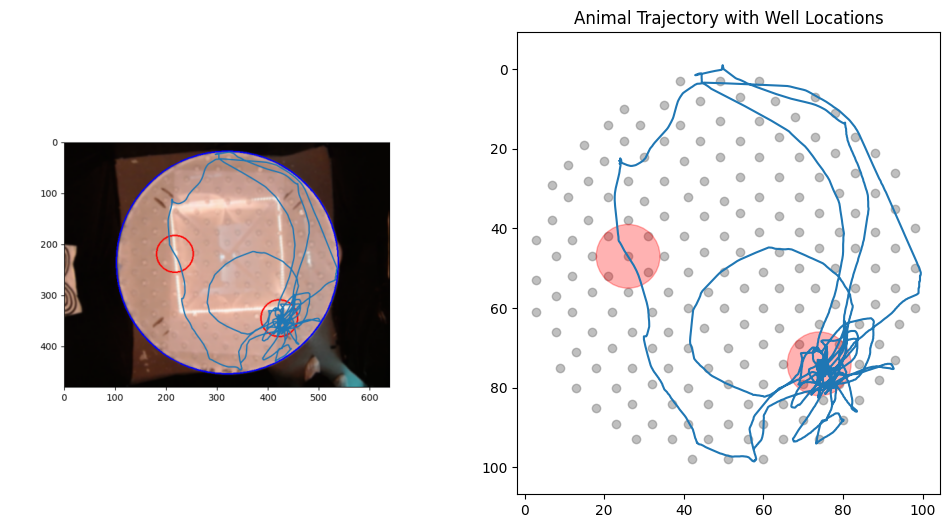

In [4]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1,2,figsize=(12,6), width_ratios=(1, 1))

axes[0].imshow(img)
axes[0].axis('off')

axes[1].plot(position['x'].values, position['y'].values)
axes[1].scatter(cheeseboardMap['x'].values, cheeseboardMap['y'].values, alpha=0.5, color='gray')
for i in range(len(triggerLoc)):
    x = triggerLoc['x'][i]
    y = triggerLoc['y'][i]
    circle = plt.Circle((x, y), 8, color='r', fill=True, linestyle='-', alpha=0.3)
    axes[1].add_artist(circle)
# Equalize axis scales
axes[1].axis('equal')
# axes[1].axis('off')
# Flip the y-axis to match the coordinate system
axes[1].invert_yaxis()
axes[1].set_title('Animal Trajectory with Well Locations')

In [5]:
triggerLoc

,well_row,well_col,x,y
0,J,3,26,47
1,Q,8,74,74


In [6]:
position_ = add_dist_to_trigger(position, triggerLoc)
trigger_num = len(triggerLoc)
dfs = []
for i in range(trigger_num):
    df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
    df_trigger_interaction["trigger_id"] = i + 1
    dfs.append(df_trigger_interaction)
df_all_triggers = pd.concat(dfs, ignore_index=True)
df_all_triggers

,t_enter,t_exit,duration,trigger_id
0,160470,161746,1276,1
1,2017,7183,5166,2
2,8962,14420,5458,2
3,18488,23541,5053,2
4,23672,25425,1753,2
5,28682,31495,2813,2
6,33670,60280,26610,2
7,63489,80872,17383,2
8,82751,86006,3255,2
9,87337,89477,2140,2


### Compute the time animal took to reach the trigger zone

In [12]:
metadata


,sub,id,date,ses,trial_id,trial_type,trial_type_day,test_type,usable,trial_note,genotype,test_order,remapping,short_duration,LFP,animal_note,t_to_trigger,learned
0,1.0,A,20241205.0,1.0,1.0,H,1.0,NaN,1.0,NaN,ChR2,e,0.0,0.0,0.0,NaN,107916.0,True
1,1.0,A,20241205.0,1.0,2.0,H,1.0,NaN,1.0,NaN,ChR2,e,0.0,0.0,0.0,NaN,33656.0,True
2,1.0,A,20241205.0,1.0,3.0,H,1.0,NaN,1.0,NaN,ChR2,e,0.0,0.0,0.0,NaN,12902.0,True
3,1.0,A,20241205.0,1.0,4.0,H,1.0,NaN,1.0,NaN,ChR2,e,0.0,0.0,0.0,NaN,1990.0,True
4,1.0,A,20241205.0,1.0,5.0,H,1.0,NaN,1.0,NaN,ChR2,e,0.0,0.0,0.0,NaN,99625.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4106,46.0,AV,20250813.0,8.0,6.0,L,5.0,NaN,1.0,NaN,Hp,NaN,0.0,0.0,0.0,NaN,0.0,False
4107,46.0,AV,20250813.0,8.0,7.0,L,5.0,NaN,1.0,NaN,Hp,NaN,0.0,0.0,0.0,NaN,0.0,False
4108,46.0,AV,20250813.0,8.0,8.0,L,5.0,NaN,1.0,NaN,Hp,NaN,0.0,0.0,0.0,NaN,0.0,False
4109,46.0,AV,20250814.0,9.0,1.0,T,1.0,NaN,1.0,NaN,Hp,NaN,0.0,0.0,0.0,NaN,0.0,False


In [13]:
metadata = util.load_metadata()
metadata = metadata[metadata['usable'] == 1].reset_index(drop=True)  # <-- only recruit the trials if usable = 1

# Define a column in metadata to save the time to trigger zone
metadata['t_to_trigger'] = 0
# Define another column to save if animal ever learned to stay at the trigger zone
metadata['learned'] = False

for trial_id in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[trial_id])
    position = dl.get_data('position')
    if position is None:
        continue
    cheeseboardMap = util.load_cheeseboard_map()
    triggerLoc = dl.get_data('triggerLoc')

    position_ = add_dist_to_trigger(position, triggerLoc)

    trigger_num = len(triggerLoc)
    dfs = []
    for i in range(trigger_num):
        df_trigger_interaction = get_interaction_with_trigger_df(position_, 8, ti = i+1)
        df_trigger_interaction["trigger_id"] = i + 1
        dfs.append(df_trigger_interaction)
    if dfs == []:
        print(f'{dl.id}, {dl.ses_dir} likely triggerLoc missing')
        t_to_trigger = position_.iloc[-1]['t']
        continue
    df_all_triggers = pd.concat(dfs, ignore_index=True)
    # Order dataframe by t_enter
    df_all_triggers = df_all_triggers.sort_values(by='t_enter').reset_index(drop=True)
    # Find time to trigger
    df_all_triggers_long = df_all_triggers[df_all_triggers['duration']>2000]
    if len(df_all_triggers_long) == 0:
        # If animal never spent more than dt in the trigger zone, time to trigger is equal to the duration of the trial
        t_to_trigger = position_.iloc[-1]['t']
        
    else:
        t_to_trigger = df_all_triggers_long.iloc[0]['t_enter']
        metadata.at[trial_id, 'learned'] = True

    metadata.at[trial_id, 't_to_trigger'] = t_to_trigger

 20%|█▉        | 709/3576 [00:07<00:29, 98.40it/s] 

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-010_id-AF/ses-17_date-20250624/behav/sub-010_ses-17_trial-01_data-position.csv' does not exist.


 33%|███▎      | 1183/3576 [00:12<00:23, 100.66it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-014_id-AJ/ses-04_date-20250711/behav/sub-014_ses-04_trial-04_data-position.csv' does not exist.


 73%|███████▎  | 2609/3576 [00:25<00:06, 146.35it/s]

The file '/Users/stella/Desktop/PhD/paulsen_lab/Analysis/kou_analysis/cheeseboard-data/derivatives/sub-031_id-I/ses-05_date-20241201/behav/sub-031_ses-05_trial-03_data-position.csv' does not exist.


100%|██████████| 3576/3576 [00:34<00:00, 103.36it/s]


([<matplotlib.axis.XTick at 0x11b2ffbd0>,
 [Text(0, 0, 'Day 1'),
  Text(1, 0, 'Day 2'),
  Text(2, 0, 'Day 3'),
  Text(3, 0, 'Day 4'),
  Text(4, 0, 'Day 5')])

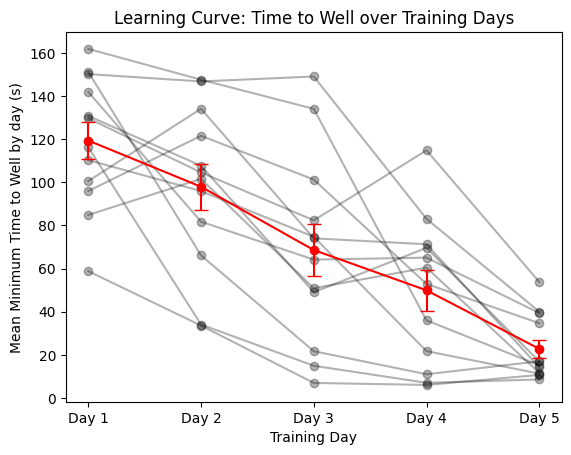

In [14]:
metadata_L = metadata[
    (metadata['trial_type'] == 'L') &
    (metadata['genotype'] == 'ChR2')
    ].reset_index(drop=True)

# 

performance_mat = []
for sub in metadata_L['sub'].unique():
    metadata_L_A = metadata_L[metadata_L['sub'] == sub]#.reset_index(drop=True)
    mean_performance_by_day = metadata_L_A.groupby('trial_type_day')['t_to_trigger'].mean().values
    if len(mean_performance_by_day)!=5:
        continue
    performance_mat.append(mean_performance_by_day)
    plt.plot(range(0,5), mean_performance_by_day/1000, '-o',color='k', alpha=0.3)

performance_mat = np.vstack(performance_mat)
# Get the mean and standard error across subjects
mean_performance = np.nanmean(performance_mat, axis=0)
sem_performance = np.nanstd(performance_mat, axis=0) / np.sqrt(performance_mat.shape[0])
plt.errorbar(range(0,5), mean_performance/1000, yerr=sem_performance/1000, fmt='-o', color='r', capsize=5)
plt.xlabel('Training Day')
plt.ylabel('Mean Minimum Time to Well by day (s)')
plt.title('Learning Curve: Time to Well over Training Days')

plt.xticks(range(0,5), labels=['Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5'])

In [ ]:
metadata_L['sub'].unique()

In [ ]:

cheeseboardMap = util.load_cheeseboard_map()
metadata = util.load_metadata()

# Create a column for minimum time to well in the metadata
metadata['min_time_to_well'] = np.nan

for idx in tqdm(range(len(metadata))):
    dl = DataLoader(metadata.iloc[idx])
    position = dl.get_data('position')
    if position is None:
        continue
    x_loc = position['smooth_trans_x'].values
    y_loc = position['smooth_trans_y'].values
    in_roi = position['inside_roi'].values
    x_loc[x_loc == -1] = np.nan
    y_loc[y_loc == -1] = np.nan



    # Get the trigger locations
    well_coords = []
    for i in range(len(triggerLoc)):
        cheeseboardMap_loc = cheeseboardMap[(cheeseboardMap['well_row'] == triggerLoc['well_row'].values[i]) & (cheeseboardMap['well_col'] == triggerLoc['well_col'].values[i])]
        well_coords.append((cheeseboardMap_loc['trans_X'].values[0], cheeseboardMap_loc['trans_Y'].values[0]))


    well_behav_metrics = compute_well_behav_metrics_all(x_loc, y_loc, well_coords)
    if np.nansum(well_behav_metrics['fraction_time_in_well']) == 0:
        continue
    min_time_to_well = np.nanmin(well_behav_metrics['time_to_arrive_zone'].values)
    metadata.at[idx, 'min_time_to_well'] = min_time_to_well

In [ ]:
metadata_L = metadata[metadata['trial_type'] == 'L']#.reset_index(drop=True)

In [ ]:
metadata_L_A = metadata_L[metadata_L['sub'] == 1]

plt.plot(metadata_L_A['min_time_to_well'])